## Load BERT to extract embeddings

In [2]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel

In [3]:
tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base", use_fast=True)
em_model  = AutoModel.from_pretrained("answerdotai/ModernBERT-base").eval()

import torch.nn.functional as F

def extract_target_vector(template: str, target: str):
    # 2. 用 target 替换 [MASK]
    filled = template.replace("[MASK]", target)

    # 3. 分词并拿到 offset_mapping
    #    返回 input_ids, attention_mask, offset_mapping
    inputs = tokenizer(
        filled,
        return_tensors="pt",
        return_offsets_mapping=True,
    )
    offsets = inputs.pop("offset_mapping")[0].tolist()  # [(s0,e0), (s1,e1), ...]

    # 4. 找到目标词在字符级的 span
    start_char = filled.find(target)
    if start_char < 0:
        raise ValueError(f"在句子里没找到目标词 {target!r}")
    end_char = start_char + len(target)

    # 5. 选出所有 offset 与 [start_char, end_char) 重叠的 token idx
    token_indices = [
        i for i, (s, e) in enumerate(offsets)
        if not (e <= start_char or s >= end_char)
    ]
    if not token_indices:
        raise ValueError(f"{target!r} 的字符 span 对应不到任何 token。")

    # 6. 前向计算隐藏态
    with torch.no_grad():
        last_hidden = em_model(**inputs).last_hidden_state.squeeze(0)  # (seq_len, hidden_dim)

    # 7. 平均选中 token 的向量
    return last_hidden[token_indices].mean(dim=0)

def compute_avg_vector(target: str, templates: list[str]):
    # 针对每个模板都提一次，再对所有模板的结果做平均
    vecs = [extract_target_vector(tpl, target) for tpl in templates]
    return torch.stack(vecs, dim=0).mean(dim=0)

templates = [
    "This music sounds [MASK].",  
    "The overall tone of this music is [MASK].",   
    "The spectral balance and tonal quality of this music feel [MASK], defining its timbre.",  
]

In [4]:
mmax = np.ones((40,)) * 4
mmin = np.ones((40,)) * -4

## Load the trained model and listen

In [ ]:
# Using Gammatone to apply filters
!pip install git+https://github.com/detly/gammatone.git

In [5]:
from gammatone import filters 
import soundfile as sf
import IPython.display

In [6]:
# Load and listen to original audio sample

x, fs = sf.read('e_gtr_short.wav')
print(f"Loaded {x.shape[0]} samples at fs={fs}")
IPython.display.Audio(x,rate=fs)

Loaded 458317 samples at fs=44100


In [7]:
# Create filters
c_freqs = filters.centre_freqs(fs, 40, 20)
fcoefs = filters.make_erb_filters(fs, c_freqs, width=1.0)

# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
filterbank_x = filters.erb_filterbank(x, fcoefs)

1/1 [==============================] - 0s 39ms/step


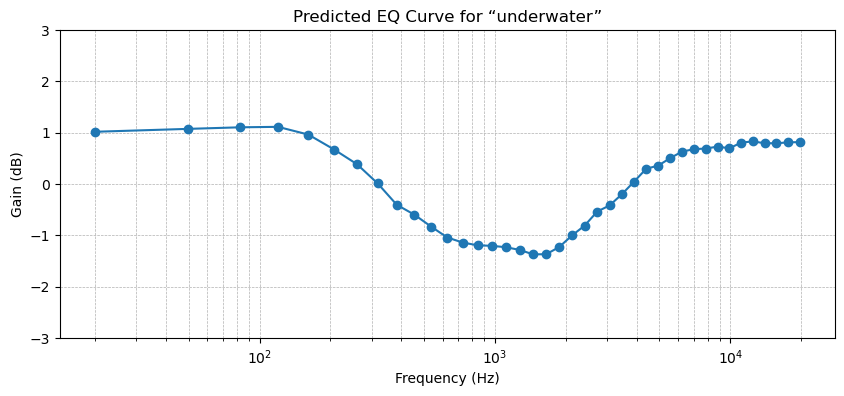

In [22]:
test_words = 'underwater'
test_model = keras.models.load_model('BERT_FourthFold_MAE.keras')
test_vec   = compute_avg_vector(test_words,templates)

test_vec = test_vec.detach().cpu().numpy()   # 转换为 numpy 数组
test_vec = test_vec.reshape(1, -1)            # 确保形状为 (1, 768)
p = test_model.predict(test_vec)

# y_test = (y_test - mmin) / (mmax - mmin)
p = p * (mmax - mmin) + mmin

# 假设 p 已经是反归一化后的预测结果，形状 (1,40)
gains_db = np.flip(1.5*p[0])  

# c_freqs 由你之前计算过
# c_freqs = filters.centre_freqs(fs, 40, 20)

plt.figure(figsize=(10,4))
plt.plot(c_freqs, gains_db, marker='o')      
plt.xscale('log')                             
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.ylim(-3.0, +3.0)
plt.title(f"Predicted EQ Curve for “{test_words}”")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * np.flip(1.5*p[0, :]),axis=1)
IPython.display.Audio(out,rate=fs)